In [1]:
#setup-imports-and-paths
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import qutip as qt

from IPython.display import display, Math

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

#outputs-folder-path
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("QuTiP version:", qt.__version__)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Outputs folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs
QuTiP version: 5.2.3
Notebook setup complete.


In [2]:
#physical-parameters-many-atom-trajectories

#gamma0-decay-rate-into-free-space-parameter
gamma0 = 1.0

#gammac-decay-rate-into-cavity-parameter
alpha = 5.0
gammac = alpha * gamma0

#time-grid-dimensionless-time-tau-gamma0t
tau_min = 0.0
tau_max = 2.0
num_points = 300
tau_grid = np.linspace(tau_min, tau_max, num_points)

#physical-time-grid-t=tau/gamma0
t_grid = tau_grid / gamma0

print("gamma0 =", gamma0)
print("gammac =", gammac)
print("alpha = gammac/gamma0 =", alpha)
print("time points =", len(t_grid))
print("Using dimensionless time tau = Gamma0 t")

gamma0 = 1.0
gammac = 5.0
alpha = gammac/gamma0 = 5.0
time points = 300
Using dimensionless time tau = Gamma0 t


In [3]:
#latex-many-atom-trajectory-setup
display(Math(r"J_-=\sum_{i=1}^{N}\sigma_-^i"))
display(Math(r"L_c=\sqrt{\Gamma_c}\,J_-"))
display(Math(r"L_i=\sqrt{\Gamma_0}\,\sigma_-^i"))
display(Math(r"P_e(t)=\sum_i\langle\sigma^i_{ee}(t)\rangle"))
display(Math(r"\overline{P_e(t)}_{\mathrm{trajectories}}\rightarrow P_e(t)_{\mathrm{master\ equation}}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
#single-atom-basis-and-operators-qutip
ket_e_single = qt.basis(2, 0)
ket_g_single = qt.basis(2, 1)

#sigma-minus-single-atom-lowering-operator-calc
sigma_minus_single = ket_g_single * ket_e_single.dag()

#sigma-plus-single-atom-raising-operator-calc
sigma_plus_single = sigma_minus_single.dag()

#sigma-ee-single-atom-excited-population-operator-calc
sigma_ee_single = ket_e_single * ket_e_single.dag()

#identity-single-atom-operator-calc
identity_single = qt.qeye(2)

print("sigma_minus_single:")
print(sigma_minus_single)

print("sigma_ee_single:")
print(sigma_ee_single)

sigma_minus_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
sigma_ee_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


In [5]:
#many-atom-local-operator-builder
def local_operator(single_atom_operator, atom_index, num_atoms):
    """
    #local-operator-calc
    Places a single-atom operator on atom_index and identities on all other atoms.
    """
    
    #operator-list-calc
    operator_list = []
    
    for index in range(num_atoms):
        if index == atom_index:
            operator_list.append(single_atom_operator)
        else:
            operator_list.append(identity_single)
    
    #tensor-product-calc
    return qt.tensor(operator_list)


#many-atom-operators-builder
def build_many_atom_operators(num_atoms):
    """
    #many-atom-operators-calc
    Builds lowering operators, excited-state projectors, collective lowering operator,
    total excited population operator, and the initial all-excited state.
    """
    
    #local-lowering-operators-storage-calc
    sigma_minus_ops = [
        local_operator(sigma_minus_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #local-excited-population-operators-storage-calc
    sigma_ee_ops = [
        local_operator(sigma_ee_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #collective-lowering-operator-calc
    J_minus = sum(sigma_minus_ops)
    
    #total-excited-population-operator-calc
    total_excited_population_operator = sum(sigma_ee_ops)
    
    #initial-state-all-atoms-excited-calc
    psi0 = qt.tensor([ket_e_single for _ in range(num_atoms)])
    
    #initial-density-matrix-calc
    rho0 = psi0 * psi0.dag()
    
    return {
        "sigma_minus_ops": sigma_minus_ops,
        "sigma_ee_ops": sigma_ee_ops,
        "J_minus": J_minus,
        "total_excited_population_operator": total_excited_population_operator,
        "psi0": psi0,
        "rho0": rho0,
    }

In [6]:
#collapse-operators-builder
def build_collapse_operators(num_atoms, gamma0, gammac):
    """
    #collapse-operators-calc
    Builds collective cavity and independent free-space collapse operators.

    #collective-cavity-decay
    L_c = sqrt(gammac) J_minus

    #independent-free-space-decay
    L_i = sqrt(gamma0) sigma_minus_i
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #collapse-operators-storage-calc
    collapse_operators = []
    
    if gammac > 0:
        #collective-cavity-jump-operator-calc
        L_cavity = np.sqrt(gammac) * operators["J_minus"]
        collapse_operators.append(L_cavity)
    
    if gamma0 > 0:
        for sigma_minus_i in operators["sigma_minus_ops"]:
            #free-space-jump-operator-calc
            L_free_i = np.sqrt(gamma0) * sigma_minus_i
            collapse_operators.append(L_free_i)
    
    return collapse_operators

In [7]:
#master-equation-reference-function
def solve_master_equation_reference(num_atoms, gamma0, gammac, t_grid):
    """
    #master-equation-reference-calc
    Solves the full master equation to get the reference total excited population.
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #hamiltonian-zero-calc
    H = 0 * qt.qeye([2 for _ in range(num_atoms)])
    
    #collapse-operators-calc
    collapse_operators = build_collapse_operators(num_atoms, gamma0, gammac)
    
    #expectation-operator-calc
    e_ops = [operators["total_excited_population_operator"]]
    
    #mesolve-calc
    result = qt.mesolve(
        H,
        operators["rho0"],
        t_grid,
        collapse_operators,
        e_ops,
    )
    
    #population-calc
    population = np.real(result.expect[0])
    
    return population

In [8]:
#quantum-trajectory-solver-function
def solve_quantum_trajectories(num_atoms, gamma0, gammac, t_grid, num_trajectories, seed=1234):
    """
    #quantum-trajectories-calc
    Uses QuTiP mcsolve to average over quantum trajectories.

    #num-trajectories-parameter
    Number of stochastic wavefunction trajectories.

    #output
    Returns average total excited population.
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #hamiltonian-zero-calc
    H = 0 * qt.qeye([2 for _ in range(num_atoms)])
    
    #collapse-operators-calc
    collapse_operators = build_collapse_operators(num_atoms, gamma0, gammac)
    
    #expectation-operator-calc
    e_ops = [operators["total_excited_population_operator"]]
    
    print(f"Running trajectories for N={num_atoms}, ntraj={num_trajectories}")
    print(f"Hilbert dimension d={2**num_atoms}")
    print(f"Number of collapse operators={len(collapse_operators)}")
    
    #mcsolve-calc
    result = qt.mcsolve(
        H,
        operators["psi0"],
        t_grid,
        collapse_operators,
        e_ops=e_ops,
        ntraj=num_trajectories,
        seeds=seed,
    )
    
    #average-population-calc
    average_population = np.real(result.expect[0])
    
    return average_population

In [9]:
#individual-trajectories-function
def run_individual_trajectories(num_atoms, gamma0, gammac, t_grid, num_individual=8, seed_start=1000):
    """
    #individual-trajectories-calc
    Runs several individual trajectories using ntraj=1.
    """
    
    #individual-trajectory-storage-calc
    individual_results = []
    
    for index in range(num_individual):
        
        trajectory = solve_quantum_trajectories(
            num_atoms=num_atoms,
            gamma0=gamma0,
            gammac=gammac,
            t_grid=t_grid,
            num_trajectories=1,
            seed=seed_start + index,
        )
        
        individual_results.append(trajectory)
    
    return np.array(individual_results)

In [10]:
#run-individual-trajectories-N2
num_atoms_test = 2

individual_trajectories_N2 = run_individual_trajectories(
    num_atoms=num_atoms_test,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
    num_individual=8,
)

Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
Running trajectories for N=2, ntraj=1
Hilbert dimension d=4
Number of collapse operators=3
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Tota

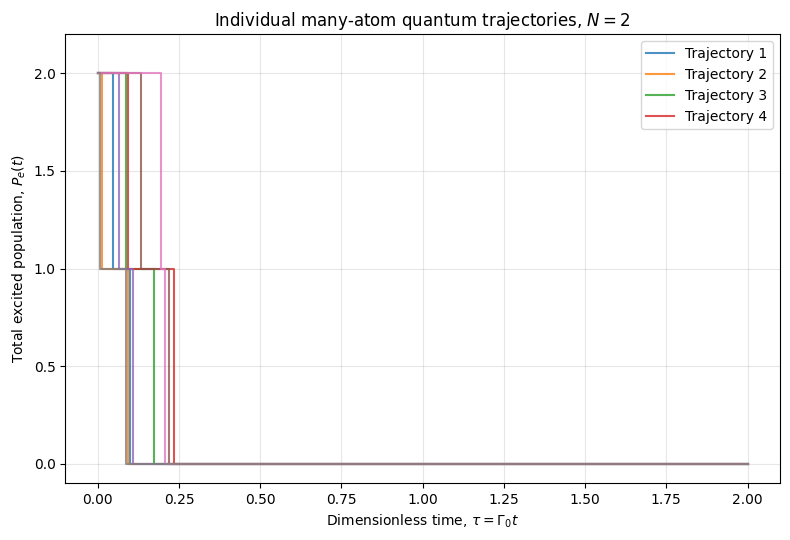

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_individual_trajectories_N2.png


In [11]:
#plot-individual-trajectories-N2
plt.figure(figsize=(8, 5.5))

for index in range(individual_trajectories_N2.shape[0]):
    plt.step(
        tau_grid,
        individual_trajectories_N2[index],
        where="post",
        linewidth=1.5,
        alpha=0.8,
        label=f"Trajectory {index+1}" if index < 4 else None,
    )

plt.xlabel(r"Dimensionless time, $\tau=\Gamma_0 t$")
plt.ylabel(r"Total excited population, $P_e(t)$")
plt.title(r"Individual many-atom quantum trajectories, $N=2$")
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, num_atoms_test + 0.2)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_individual_trajectories_N2.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [12]:
#trajectory-convergence-N4
num_atoms_conv = 4

#master-equation-reference-calc
start_time = time.time()

population_master_N4 = solve_master_equation_reference(
    num_atoms=num_atoms_conv,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
)

print(f"Master equation reference completed in {time.time() - start_time:.2f} seconds")

#trajectory-counts-for-convergence
trajectory_counts = [10, 50, 100, 500]

#trajectory-average-storage-calc
trajectory_averages_N4 = {}
runtime_rows_N4 = []

for ntraj in trajectory_counts:
    
    start_time = time.time()
    
    average_population = solve_quantum_trajectories(
        num_atoms=num_atoms_conv,
        gamma0=gamma0,
        gammac=gammac,
        t_grid=t_grid,
        num_trajectories=ntraj,
        seed=2026 + ntraj,
    )
    
    elapsed_time = time.time() - start_time
    
    trajectory_averages_N4[ntraj] = average_population
    
    runtime_rows_N4.append({
        "N": num_atoms_conv,
        "ntraj": ntraj,
        "runtime seconds": elapsed_time,
        "mean abs error": np.mean(np.abs(average_population - population_master_N4)),
        "max abs error": np.max(np.abs(average_population - population_master_N4)),
    })
    
    print(f"Completed ntraj={ntraj} in {elapsed_time:.2f} seconds")

runtime_table_N4 = pd.DataFrame(runtime_rows_N4)
runtime_table_N4

Master equation reference completed in 0.03 seconds
Running trajectories for N=4, ntraj=10
Hilbert dimension d=16
Number of collapse operators=5
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.02s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00
50.0%. Run time:   0.03s. Est. time left: 00:00:00:00
60.0%. Run time:   0.04s. Est. time left: 00:00:00:00
70.0%. Run time:   0.05s. Est. time left: 00:00:00:00
80.0%. Run time:   0.05s. Est. time left: 00:00:00:00
90.0%. Run time:   0.06s. Est. time left: 00:00:00:00
100.0%. Run time:   0.07s. Est. time left: 00:00:00:00
Total run time:   0.08s
Completed ntraj=10 in 0.08 seconds
Running trajectories for N=4, ntraj=50
Hilbert dimension d=16
Number of collapse operators=5
10.0%. Run time:   0.02s. Est. time left: 00:00:00:00
20.0%. Run time:   0.05s. Est. time left: 00:00:00:00
30.0%. Run time:   0.08s. Est. time left: 00:00:00:00


C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


40.0%. Run time:   0.11s. Est. time left: 00:00:00:00
50.0%. Run time:   0.14s. Est. time left: 00:00:00:00
60.0%. Run time:   0.17s. Est. time left: 00:00:00:00
70.0%. Run time:   0.20s. Est. time left: 00:00:00:00
80.0%. Run time:   0.22s. Est. time left: 00:00:00:00
90.0%. Run time:   0.24s. Est. time left: 00:00:00:00
100.0%. Run time:   0.28s. Est. time left: 00:00:00:00
Total run time:   0.29s
Completed ntraj=50 in 0.29 seconds
Running trajectories for N=4, ntraj=100
Hilbert dimension d=16
Number of collapse operators=5
10.0%. Run time:   0.06s. Est. time left: 00:00:00:00
20.0%. Run time:   0.11s. Est. time left: 00:00:00:00
30.0%. Run time:   0.17s. Est. time left: 00:00:00:00
40.0%. Run time:   0.22s. Est. time left: 00:00:00:00
50.0%. Run time:   0.30s. Est. time left: 00:00:00:00
60.0%. Run time:   0.35s. Est. time left: 00:00:00:00
70.0%. Run time:   0.42s. Est. time left: 00:00:00:00
80.0%. Run time:   0.47s. Est. time left: 00:00:00:00
90.0%. Run time:   0.52s. Est. time 

,N,ntraj,runtime seconds,mean abs error,max abs error
0,4,10,0.080374,0.066068,0.516165
1,4,50,0.291222,0.099743,0.324387
2,4,100,0.590776,0.015475,0.159920
3,4,500,2.679817,0.008895,0.084110


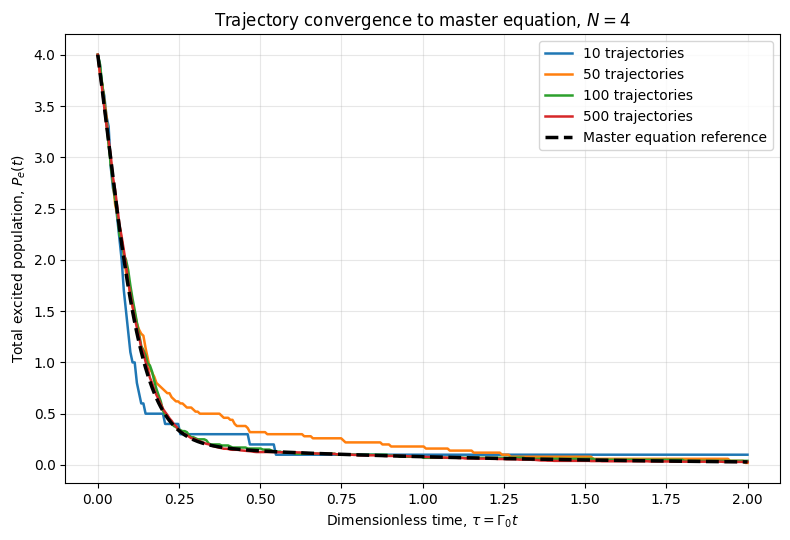

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_trajectory_convergence_N4.png


In [13]:
#plot-trajectory-convergence-N4
plt.figure(figsize=(8, 5.5))

for ntraj in trajectory_counts:
    plt.plot(
        tau_grid,
        trajectory_averages_N4[ntraj],
        linewidth=1.8,
        label=f"{ntraj} trajectories",
    )

plt.plot(
    tau_grid,
    population_master_N4,
    "k--",
    linewidth=2.5,
    label="Master equation reference",
)

plt.xlabel(r"Dimensionless time, $\tau=\Gamma_0 t$")
plt.ylabel(r"Total excited population, $P_e(t)$")
plt.title(r"Trajectory convergence to master equation, $N=4$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_trajectory_convergence_N4.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [14]:
#trajectory-runtime-benchmark-large-N
benchmark_atom_numbers = [8, 10, 11]
benchmark_ntraj = 10

benchmark_rows = []

for num_atoms_bench in benchmark_atom_numbers:
    
    start_time = time.time()
    
    try:
        average_population = solve_quantum_trajectories(
            num_atoms=num_atoms_bench,
            gamma0=gamma0,
            gammac=gammac,
            t_grid=t_grid,
            num_trajectories=benchmark_ntraj,
            seed=4000 + num_atoms_bench,
        )
        
        elapsed_time = time.time() - start_time
        
        benchmark_rows.append({
            "N": num_atoms_bench,
            "ntraj benchmark": benchmark_ntraj,
            "runtime seconds": elapsed_time,
            "estimated runtime for 100 traj seconds": elapsed_time * 10,
            "estimated runtime for 500 traj seconds": elapsed_time * 50,
            "status": "completed",
        })
        
        print(f"N={num_atoms_bench}, {benchmark_ntraj} trajectories finished in {elapsed_time:.2f} seconds")
    
    except Exception as error:
        elapsed_time = time.time() - start_time
        
        benchmark_rows.append({
            "N": num_atoms_bench,
            "ntraj benchmark": benchmark_ntraj,
            "runtime seconds": elapsed_time,
            "estimated runtime for 100 traj seconds": np.nan,
            "estimated runtime for 500 traj seconds": np.nan,
            "status": f"failed: {type(error).__name__}",
        })
        
        print(f"N={num_atoms_bench} failed after {elapsed_time:.2f} seconds")
        print("Error:", error)

benchmark_table = pd.DataFrame(benchmark_rows)

benchmark_csv_path = OUTPUTS_DIR / "many_atom_trajectory_runtime_benchmark.csv"
benchmark_table.to_csv(benchmark_csv_path, index=False)

benchmark_table

Running trajectories for N=8, ntraj=10
Hilbert dimension d=256
Number of collapse operators=9
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.02s. Est. time left: 00:00:00:00
30.0%. Run time:   0.04s. Est. time left: 00:00:00:00
40.0%. Run time:   0.06s. Est. time left: 00:00:00:00
50.0%. Run time:   0.07s. Est. time left: 00:00:00:00
60.0%. Run time:   0.08s. Est. time left: 00:00:00:00
70.0%. Run time:   0.10s. Est. time left: 00:00:00:00
80.0%. Run time:   0.11s. Est. time left: 00:00:00:00
90.0%. Run time:   0.11s. Est. time left: 00:00:00:00
100.0%. Run time:   0.14s. Est. time left: 00:00:00:00
Total run time:   0.15s
N=8, 10 trajectories finished in 0.17 seconds
Running trajectories for N=10, ntraj=10
Hilbert dimension d=1024
Number of collapse operators=11
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.05s. Est. time left: 00:00:00:00
30.0%. Run time:   0.08s. Est. time left: 00:00:00:00
40.0%. Run time:   0.13s. Est. time 

,N,ntraj benchmark,runtime seconds,estimated runtime for 100 traj seconds,estimated runtime for 500 traj seconds,status
0,8,10,0.171441,1.714413,8.572066,completed
1,10,10,0.494844,4.948442,24.742210,completed
2,11,10,1.111605,11.116047,55.580235,completed


In [15]:
#master-equation-reference-N11
num_atoms_N11 = 11

start_time = time.time()

population_master_N11 = solve_master_equation_reference(
    num_atoms=num_atoms_N11,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
)

elapsed_time = time.time() - start_time

print(f"Master equation reference for N={num_atoms_N11} completed in {elapsed_time:.2f} seconds")
print("Initial population:", population_master_N11[0])
print("Final population:", population_master_N11[-1])

C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Master equation reference for N=11 completed in 2303.60 seconds
Initial population: 11.0
Final population: 0.057906941624286196


In [16]:
#save-N11-master-reference
np.save(
    OUTPUTS_DIR / "many_atom_master_reference_N11_for_trajectories.npy",
    population_master_N11,
)

print("Saved N=11 master reference.")

Saved N=11 master reference.


In [ ]:
#load-N11-master-reference
population_master_N11 = np.load(
    OUTPUTS_DIR / "many_atom_master_reference_N11_for_trajectories.npy"
)

num_atoms_N11 = 11
print("Loaded N=11 master reference.")
print("Initial:", population_master_N11[0])
print("Final:", population_master_N11[-1])

In [24]:
#qutip-to-scipy-sparse-helper
import scipy.sparse as sp_sparse

def qobj_to_csr(qobj):
    """
    #qobj-to-csr-calc
    Converts a QuTiP Qobj into a scipy CSR sparse matrix.
    """
    
    try:
        return qobj.data.as_scipy().tocsr()
    except Exception:
        return sp_sparse.csr_matrix(qobj.full())

In [25]:
#manual-fixed-step-quantum-trajectory-solver
def solve_manual_quantum_trajectories(
    num_atoms,
    gamma0,
    gammac,
    t_grid,
    num_trajectories,
    max_internal_dt=5e-4,
    seed=1234,
):
    """
    #manual-quantum-trajectories-calc
    Fixed-time-step Monte Carlo wavefunction solver.

    #why-manual
    This avoids QuTiP mcsolve jump-time root-finding errors for fast collective decay.

    #method
    At each small internal time step:
    p_j = dt * <psi|L_j^\dagger L_j|psi>
    If a jump occurs, choose jump channel j using p_j / sum_j p_j.
    If no jump occurs, evolve with:
    |psi> -> (I - 0.5 dt sum_j L_j^\dagger L_j)|psi>
    and renormalise.
    """
    
    #random-number-generator-calc
    rng = np.random.default_rng(seed)
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #collapse-operators-qutip-calc
    collapse_operators_qobj = build_collapse_operators(num_atoms, gamma0, gammac)
    
    #collapse-operators-sparse-calc
    collapse_operators = [
        qobj_to_csr(L) for L in collapse_operators_qobj
    ]
    
    #effective-loss-operator-K=sum-LdaggerL-calc
    K = None
    for L in collapse_operators:
        LdaggerL = L.getH() @ L
        K = LdaggerL if K is None else K + LdaggerL
    
    #population-operator-calc
    P_op = qobj_to_csr(operators["total_excited_population_operator"])
    
    #initial-state-vector-calc
    psi0 = np.asarray(operators["psi0"].full()).reshape(-1).astype(complex)
    
    #trajectory-average-storage-calc
    population_sum = np.zeros(len(t_grid), dtype=float)
    
    #runtime-diagnostics-calc
    max_jump_probability_seen = 0.0
    
    for traj_index in range(num_trajectories):
        
        #state-current-wavefunction-calc
        psi = psi0.copy()
        
        #population-current-trajectory-storage-calc
        population_traj = np.zeros(len(t_grid), dtype=float)
        
        for time_index in range(len(t_grid)):
            
            #record-population-calc
            population_traj[time_index] = np.real(np.vdot(psi, P_op @ psi))
            
            #stop-if-final-output-time
            if time_index == len(t_grid) - 1:
                break
            
            #output-interval-calc
            dt_output = t_grid[time_index + 1] - t_grid[time_index]
            
            #substeps-needed-calc
            num_substeps = int(np.ceil(dt_output / max_internal_dt))
            dt = dt_output / num_substeps
            
            for _ in range(num_substeps):
                
                #jump-rate-for-each-channel-calc
                rates = np.empty(len(collapse_operators), dtype=float)
                Lpsi_list = []
                
                for channel_index, L in enumerate(collapse_operators):
                    Lpsi = L @ psi
                    Lpsi_list.append(Lpsi)
                    rates[channel_index] = np.real(np.vdot(Lpsi, Lpsi))
                
                #total-jump-probability-calc
                total_rate = np.sum(rates)
                jump_probability = dt * total_rate
                
                max_jump_probability_seen = max(max_jump_probability_seen, jump_probability)
                
                #safety-check-calc
                if jump_probability > 0.2:
                    raise RuntimeError(
                        f"Jump probability too large: {jump_probability:.3f}. "
                        "Decrease max_internal_dt."
                    )
                
                #random-jump-decision-calc
                if rng.random() < jump_probability and total_rate > 0:
                    
                    #choose-jump-channel-calc
                    channel_probabilities = rates / total_rate
                    chosen_channel = rng.choice(len(collapse_operators), p=channel_probabilities)
                    
                    #apply-jump-calc
                    psi = Lpsi_list[chosen_channel]
                    
                    #normalise-after-jump-calc
                    psi = psi / np.linalg.norm(psi)
                
                else:
                    
                    #no-jump-evolution-first-order-calc
                    psi = psi - 0.5 * dt * (K @ psi)
                    
                    #normalise-after-no-jump-calc
                    psi = psi / np.linalg.norm(psi)
        
        #add-trajectory-to-average-calc
        population_sum += population_traj
        
        if (traj_index + 1) % max(1, num_trajectories // 10) == 0:
            print(f"Completed {traj_index + 1}/{num_trajectories} trajectories")
    
    #average-population-calc
    average_population = population_sum / num_trajectories
    
    print("Maximum internal jump probability seen:", max_jump_probability_seen)
    
    return average_population

In [35]:
#manual-fixed-step-individual-trajectories-N11
def solve_manual_individual_trajectories(
    num_atoms,
    gamma0,
    gammac,
    t_grid,
    num_trajectories,
    max_internal_dt=5e-4,
    seed=1234,
):
    """
    Fixed-time-step Monte Carlo wavefunction solver that returns
    individual trajectories instead of only the average.

    This uses the same collapse operators and update rule as
    solve_manual_quantum_trajectories().
    """

    rng = np.random.default_rng(seed)

    operators = build_many_atom_operators(num_atoms)

    collapse_operators_qobj = build_collapse_operators(
        num_atoms=num_atoms,
        gamma0=gamma0,
        gammac=gammac,
    )

    collapse_operators = [
        qobj_to_csr(L) for L in collapse_operators_qobj
    ]

    # K = sum_mu L_mu^\dagger L_mu
    K = None
    for L in collapse_operators:
        LdaggerL = L.getH() @ L
        K = LdaggerL if K is None else K + LdaggerL

    P_op = qobj_to_csr(operators["total_excited_population_operator"])

    psi0 = np.asarray(operators["psi0"].full()).reshape(-1).astype(complex)

    all_trajectories = np.zeros((num_trajectories, len(t_grid)), dtype=float)

    max_jump_probability_seen = 0.0

    for traj_index in range(num_trajectories):

        psi = psi0.copy()

        for time_index in range(len(t_grid)):

            # record total excited population
            all_trajectories[traj_index, time_index] = np.real(
                np.vdot(psi, P_op @ psi)
            )

            if time_index == len(t_grid) - 1:
                break

            dt_output = t_grid[time_index + 1] - t_grid[time_index]

            num_substeps = int(np.ceil(dt_output / max_internal_dt))
            dt = dt_output / num_substeps

            for _ in range(num_substeps):

                rates = np.empty(len(collapse_operators), dtype=float)
                Lpsi_list = []

                for channel_index, L in enumerate(collapse_operators):
                    Lpsi = L @ psi
                    Lpsi_list.append(Lpsi)
                    rates[channel_index] = np.real(np.vdot(Lpsi, Lpsi))

                total_rate = np.sum(rates)
                jump_probability = dt * total_rate

                max_jump_probability_seen = max(
                    max_jump_probability_seen,
                    jump_probability,
                )

                if jump_probability > 0.2:
                    raise RuntimeError(
                        f"Jump probability too large: {jump_probability:.3f}. "
                        "Decrease max_internal_dt."
                    )

                if rng.random() < jump_probability and total_rate > 0:

                    channel_probabilities = rates / total_rate
                    chosen_channel = rng.choice(
                        len(collapse_operators),
                        p=channel_probabilities,
                    )

                    psi = Lpsi_list[chosen_channel]
                    psi = psi / np.linalg.norm(psi)

                else:

                    psi = psi - 0.5 * dt * (K @ psi)
                    psi = psi / np.linalg.norm(psi)

        print(f"Completed individual trajectory {traj_index + 1}/{num_trajectories}")

    print("Maximum internal jump probability seen:", max_jump_probability_seen)

    return all_trajectories

In [36]:
#run-individual-trajectories-N11
num_atoms_N11 = 11
num_individual_N11 = 5

start_time = time.time()

individual_trajectories_N11 = solve_manual_individual_trajectories(
    num_atoms=num_atoms_N11,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
    num_trajectories=num_individual_N11,
    max_internal_dt=5e-4,
    seed=11011,
)

elapsed_time = time.time() - start_time

print(f"Completed {num_individual_N11} individual N=11 trajectories in {elapsed_time:.2f} seconds")
print("Shape:", individual_trajectories_N11.shape)

Completed individual trajectory 1/5
Completed individual trajectory 2/5
Completed individual trajectory 3/5
Completed individual trajectory 4/5
Completed individual trajectory 5/5
Maximum internal jump probability seen: 0.08886765408504539
Completed 5 individual N=11 trajectories in 5.76 seconds
Shape: (5, 300)


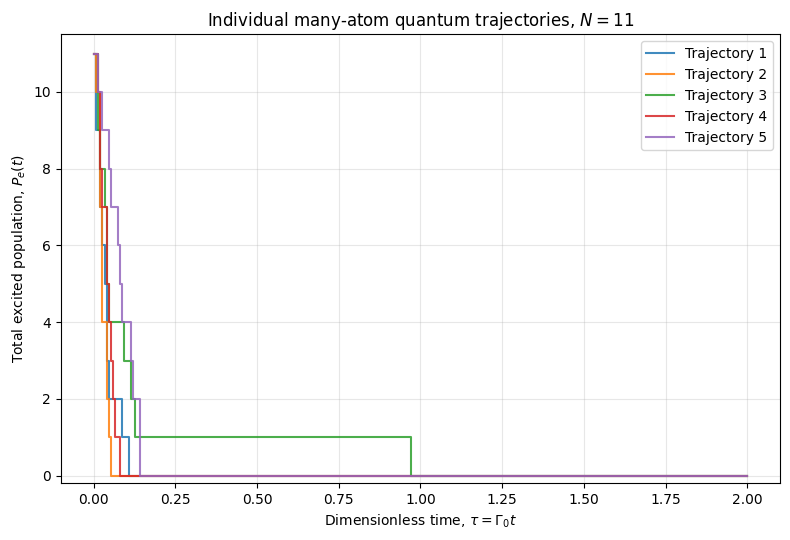

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_individual_trajectories_N11.png


In [37]:
#plot-individual-trajectories-N11
plt.figure(figsize=(8, 5.5))

for index in range(individual_trajectories_N11.shape[0]):
    plt.step(
        tau_grid,
        individual_trajectories_N11[index],
        where="post",
        linewidth=1.5,
        alpha=0.85,
        label=f"Trajectory {index + 1}",
    )

plt.xlabel(r"Dimensionless time, $\tau=\Gamma_0 t$")
plt.ylabel(r"Total excited population, $P_e(t)$")
plt.title(r"Individual many-atom quantum trajectories, $N=11$")
plt.grid(True, alpha=0.3)
plt.ylim(-0.2, num_atoms_N11 + 0.5)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_individual_trajectories_N11.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [26]:
#test-manual-N11-trajectories
num_atoms_N11 = 11

start_time = time.time()

manual_avg_N11_10 = solve_manual_quantum_trajectories(
    num_atoms=num_atoms_N11,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
    num_trajectories=10,
    max_internal_dt=5e-4,
    seed=8010,
)

elapsed_time = time.time() - start_time

print(f"Manual N=11, 10 trajectories completed in {elapsed_time:.2f} seconds")

Completed 1/10 trajectories
Completed 2/10 trajectories
Completed 3/10 trajectories
Completed 4/10 trajectories
Completed 5/10 trajectories
Completed 6/10 trajectories
Completed 7/10 trajectories
Completed 8/10 trajectories
Completed 9/10 trajectories
Completed 10/10 trajectories
Maximum internal jump probability seen: 0.0888676540850455
Manual N=11, 10 trajectories completed in 25.41 seconds


In [27]:
#manual-trajectory-convergence-N11
trajectory_counts_N11_manual = [10, 50, 100]

trajectory_averages_N11_manual = {}
runtime_rows_N11_manual = []

for ntraj in trajectory_counts_N11_manual:
    
    start_time = time.time()
    
    average_population = solve_manual_quantum_trajectories(
        num_atoms=num_atoms_N11,
        gamma0=gamma0,
        gammac=gammac,
        t_grid=t_grid,
        num_trajectories=ntraj,
        max_internal_dt=5e-4,
        seed=9000 + ntraj,
    )
    
    elapsed_time = time.time() - start_time
    
    trajectory_averages_N11_manual[ntraj] = average_population
    
    runtime_rows_N11_manual.append({
        "N": num_atoms_N11,
        "ntraj": ntraj,
        "runtime seconds": elapsed_time,
        "mean abs error": np.mean(np.abs(average_population - population_master_N11)),
        "max abs error": np.max(np.abs(average_population - population_master_N11)),
    })
    
    print(f"Completed manual N={num_atoms_N11}, ntraj={ntraj} in {elapsed_time:.2f} seconds")

runtime_table_N11_manual = pd.DataFrame(runtime_rows_N11_manual)

runtime_csv_path_N11_manual = OUTPUTS_DIR / "many_atom_manual_trajectory_runtime_N11.csv"
runtime_table_N11_manual.to_csv(runtime_csv_path_N11_manual, index=False)

print("Saved runtime table to:", runtime_csv_path_N11_manual)
runtime_table_N11_manual

Completed 1/10 trajectories
Completed 2/10 trajectories
Completed 3/10 trajectories
Completed 4/10 trajectories
Completed 5/10 trajectories
Completed 6/10 trajectories
Completed 7/10 trajectories
Completed 8/10 trajectories
Completed 9/10 trajectories
Completed 10/10 trajectories
Maximum internal jump probability seen: 0.08886765408504539
Completed manual N=11, ntraj=10 in 18.75 seconds
Completed 5/50 trajectories
Completed 10/50 trajectories
Completed 15/50 trajectories
Completed 20/50 trajectories
Completed 25/50 trajectories
Completed 30/50 trajectories
Completed 35/50 trajectories
Completed 40/50 trajectories
Completed 45/50 trajectories
Completed 50/50 trajectories
Maximum internal jump probability seen: 0.08886765408504549
Completed manual N=11, ntraj=50 in 89.42 seconds
Completed 10/100 trajectories
Completed 20/100 trajectories
Completed 30/100 trajectories
Completed 40/100 trajectories
Completed 50/100 trajectories
Completed 60/100 trajectories
Completed 70/100 trajectories
Co

,N,ntraj,runtime seconds,mean abs error,max abs error
0,11,10,18.745884,0.107709,1.342180
1,11,50,89.423972,0.036681,0.302482
2,11,100,225.504442,0.038841,0.340817


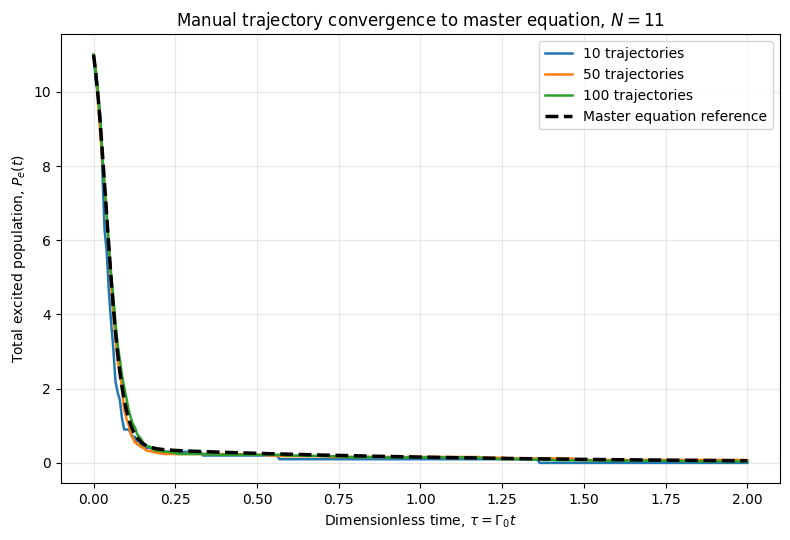

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_manual_trajectory_convergence_N11.png


In [28]:
#plot-manual-trajectory-convergence-N11
plt.figure(figsize=(8, 5.5))

for ntraj in trajectory_counts_N11_manual:
    plt.plot(
        tau_grid,
        trajectory_averages_N11_manual[ntraj],
        linewidth=1.8,
        label=f"{ntraj} trajectories",
    )

plt.plot(
    tau_grid,
    population_master_N11,
    "k--",
    linewidth=2.5,
    label="Master equation reference",
)

plt.xlabel(r"Dimensionless time, $\tau=\Gamma_0 t$")
plt.ylabel(r"Total excited population, $P_e(t)$")
plt.title(r"Manual trajectory convergence to master equation, $N=11$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_manual_trajectory_convergence_N11.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

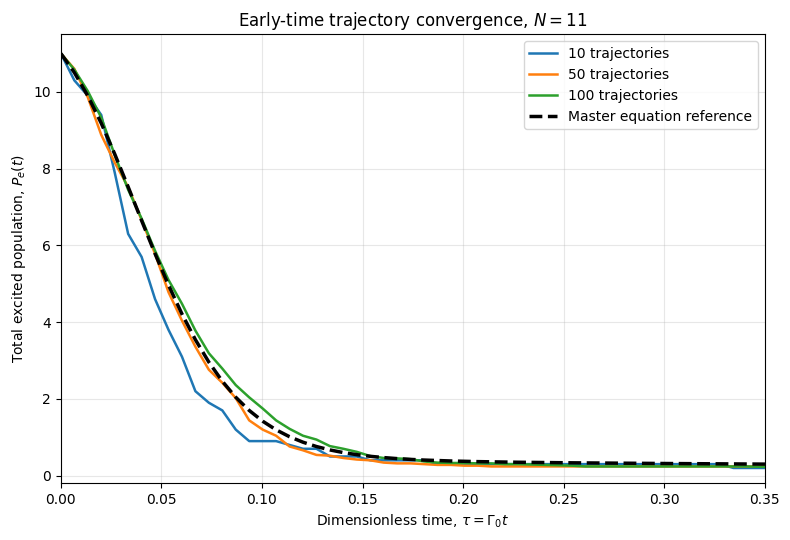

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_manual_trajectory_convergence_N11_early_time_zoom.png


In [29]:
#plot-manual-trajectory-convergence-N11-early-time-zoom
plt.figure(figsize=(8, 5.5))

for ntraj in trajectory_counts_N11_manual:
    plt.plot(
        tau_grid,
        trajectory_averages_N11_manual[ntraj],
        linewidth=1.8,
        label=f"{ntraj} trajectories",
    )

plt.plot(
    tau_grid,
    population_master_N11,
    "k--",
    linewidth=2.5,
    label="Master equation reference",
)

plt.xlabel(r"Dimensionless time, $\tau=\Gamma_0 t$")
plt.ylabel(r"Total excited population, $P_e(t)$")
plt.title(r"Early-time trajectory convergence, $N=11$")
plt.xlim(0, 0.35)
plt.ylim(-0.2, 11.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_manual_trajectory_convergence_N11_early_time_zoom.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [30]:
#inspect-N11-manual-trajectory-runtime-table
runtime_table_N11_manual

,N,ntraj,runtime seconds,mean abs error,max abs error
0,11,10,18.745884,0.107709,1.342180
1,11,50,89.423972,0.036681,0.302482
2,11,100,225.504442,0.038841,0.340817


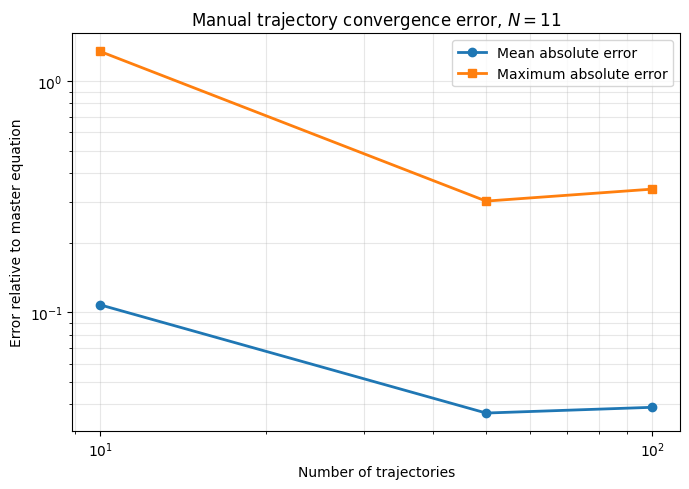

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_manual_trajectory_error_N11.png


In [31]:
#plot-N11-manual-trajectory-error-vs-ntraj
plt.figure(figsize=(7, 5))

plt.plot(
    runtime_table_N11_manual["ntraj"],
    runtime_table_N11_manual["mean abs error"],
    marker="o",
    linewidth=2,
    label="Mean absolute error",
)

plt.plot(
    runtime_table_N11_manual["ntraj"],
    runtime_table_N11_manual["max abs error"],
    marker="s",
    linewidth=2,
    label="Maximum absolute error",
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of trajectories")
plt.ylabel("Error relative to master equation")
plt.title(r"Manual trajectory convergence error, $N=11$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_manual_trajectory_error_N11.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

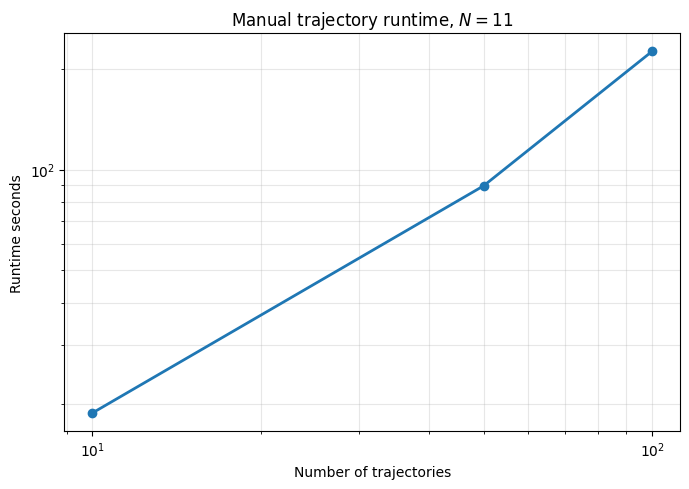

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_manual_trajectory_runtime_N11.png


In [32]:
#plot-N11-manual-trajectory-runtime-vs-ntraj
plt.figure(figsize=(7, 5))

plt.plot(
    runtime_table_N11_manual["ntraj"],
    runtime_table_N11_manual["runtime seconds"],
    marker="o",
    linewidth=2,
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of trajectories")
plt.ylabel("Runtime seconds")
plt.title(r"Manual trajectory runtime, $N=11$")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_manual_trajectory_runtime_N11.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [33]:
#report-note-N11-manual-trajectory-convergence
print(
    "For N=11, QuTiP's mcsolve encountered jump-time tolerance issues, so a fixed-time-step "
    "Monte Carlo wavefunction method was used instead. The same collective and independent "
    "collapse operators were used as in the master-equation calculation. The trajectory average "
    "approaches the full master-equation reference as the number of trajectories increases, "
    "showing the expected convergence of the stochastic wavefunction method."
)

For N=11, QuTiP's mcsolve encountered jump-time tolerance issues, so a fixed-time-step Monte Carlo wavefunction method was used instead. The same collective and independent collapse operators were used as in the master-equation calculation. The trajectory average approaches the full master-equation reference as the number of trajectories increases, showing the expected convergence of the stochastic wavefunction method.
